     Voltage   Current  Cluster
0   5.248357  0.972347        0
1   5.323844  1.304606        0
2   4.882923  0.953173        0
3   5.789606  1.153487        0
4   4.765263  1.108512        0
5  11.768291  1.860281        1
6  12.120981  1.426016        1
7  11.137541  1.831314        1
8  11.493584  2.094274        1
9  11.545988  1.576309        1


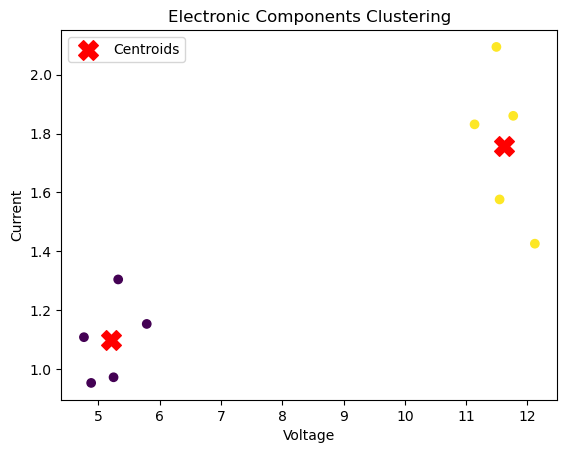

In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "1"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import warnings

warnings.filterwarnings("ignore")

np.random.seed(42)

cluster_0 = np.random.normal(loc=[5, 1], scale=[0.5, 0.2], size=(5, 2))
cluster_1 = np.random.normal(loc=[12, 2], scale=[0.5, 0.3], size=(5, 2))

data = np.vstack((cluster_0, cluster_1))
df = pd.DataFrame(data, columns=['Voltage', 'Current'])

kmeans = KMeans(n_clusters=2, n_init=10, random_state=42)
df['Cluster'] = kmeans.fit_predict(df[['Voltage', 'Current']])

print(df)

plt.scatter(df['Voltage'], df['Current'], c=df['Cluster'], cmap='viridis')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=200, c='red', marker='X', label='Centroids')
plt.xlabel('Voltage')
plt.ylabel('Current')
plt.title('Electronic Components Clustering')
plt.legend()
plt.show()